# SafeFlow AI — Financial Crime Detection
### Transaction Anomaly Detection · Money Laundering · Scam Detection

A full ML pipeline for detecting suspicious financial behaviour — covering AML (Anti-Money Laundering) patterns and transaction-level scam indicators.  
Built on the SAML-D synthetic dataset. Covers: behavioural feature engineering, anomaly scoring, supervised classification, and flagging logic.

---

## 1. Import Libraries

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from scipy.sparse import issparse

print("All libraries loaded.")

---
## 2. Data Ingestion

In [5]:
path = kagglehub.dataset_download("berkanoztas/synthetic-transaction-monitoring-dataset-aml")
finalpath = path + "/SAML-D.csv"
df = pd.read_csv(finalpath)

print(f"Dataset shape: {df.shape}")
df.info()

100%|██████████| 193M/193M [00:34<00:00, 5.85MB/s] 

Extracting files...


Dataset shape: (9504852, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Time                    object 
 1   Date                    object 
 2   Sender_account          int64  
 3   Receiver_account        int64  
 4   Amount                  float64
 5   Payment_currency        object 
 6   Received_currency       object 
 7   Sender_bank_location    object 
 8   Receiver_bank_location  object 
 9   Payment_type            object 
 10  Is_laundering           int64  
 11  Laundering_type         object 
dtypes: float64(1), int64(3), object(8)
memory usage: 870.2+ MB


In [6]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [7]:
# Class distribution check
label_counts = df['Is_laundering'].value_counts()
print("Class distribution:")
print(label_counts)
print(f"\nLaundering rate: {label_counts[1] / len(df) * 100:.4f}% of transactions")

Class distribution:
Is_laundering
0    9494979
1       9873
Name: count, dtype: int64

Laundering rate: 0.1039% of transactions


---
## 3. Data Cleaning

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

if df.isnull().sum().sum() > 0:
    df.dropna(inplace=True)
    print("\nNull rows dropped.")
else:
    print("\nNo null values found.")

Missing values per column:
Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64

No null values found.


---
## 4. Feature Engineering

This section creates meaningful signals for detecting financial crime. We engineer two categories of features:

**A. Temporal features** — unusual transaction timing (late night, weekends) is a known indicator of money laundering and scams.  
**B. Behavioural / velocity features** — derived from account-level transaction history. These are the most powerful signals in real-world financial crime detection:
- How often does this sender account transact?
- How large are their typical transactions compared to this one?
- Are they sending to many different receivers (fan-out pattern)?
- Is currency being converted (common in layering schemes)?
- Is the transaction cross-border?

> ⚠️ In the original version, `Sender_account` and `Receiver_account` were dropped entirely. This discards the most valuable information available — who is transacting, how frequently, and with whom. We use account IDs *only* to compute aggregated behavioural features, not as raw inputs.

In [9]:
# --- 4A. Temporal Features ---
df['timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df['hour_']       = df['timestamp'].dt.hour
df['day_']        = df['timestamp'].dt.dayofweek   # 0=Mon, 6=Sun
df['month_']      = df['timestamp'].dt.month
df['is_weekend']  = (df['day_'] >= 5).astype(int)  # 1 if Saturday or Sunday
df['is_night']    = ((df['hour_'] >= 22) | (df['hour_'] < 6)).astype(int)  # 1 if 10pm–6am

print("Temporal features added: hour_, day_, month_, is_weekend, is_night")

Temporal features added: hour_, day_, month_, is_weekend, is_night


In [10]:
# --- 4B. Behavioural / Velocity Features ---
# These are computed per Sender_account across the entire dataset
# (no train/test leakage risk — we are aggregating history, not the label)

sender_stats = df.groupby('Sender_account').agg(
    sender_tx_count       = ('Amount', 'count'),      # total transactions from this account
    sender_avg_amount     = ('Amount', 'mean'),        # average transaction amount
    sender_std_amount     = ('Amount', 'std'),         # variability in amounts
    sender_unique_recv    = ('Receiver_account', 'nunique'),  # number of unique recipients (fan-out)
    sender_total_amount   = ('Amount', 'sum')          # total volume sent
).reset_index()
sender_stats['sender_std_amount'] = sender_stats['sender_std_amount'].fillna(0)

receiver_stats = df.groupby('Receiver_account').agg(
    receiver_tx_count     = ('Amount', 'count'),      # total transactions into this account
    receiver_unique_send  = ('Sender_account', 'nunique')  # number of unique senders (fan-in)
).reset_index()

df = df.merge(sender_stats, on='Sender_account', how='left')
df = df.merge(receiver_stats, on='Receiver_account', how='left')

# Amount deviation from sender's own average (how unusual is this transaction for this account?)
df['amount_deviation'] = (df['Amount'] - df['sender_avg_amount']) / (df['sender_std_amount'] + 1e-9)

# Currency mismatch flag (payment currency ≠ received currency → possible layering)
df['currency_mismatch'] = (df['Payment_currency'] != df['Received_currency']).astype(int)

# Cross-border flag (sender and receiver banks in different countries)
df['cross_border'] = (df['Sender_bank_location'] != df['Receiver_bank_location']).astype(int)

print("Behavioural features added:")
print("  sender_tx_count, sender_avg_amount, sender_std_amount, sender_unique_recv, sender_total_amount")
print("  receiver_tx_count, receiver_unique_send")
print("  amount_deviation, currency_mismatch, cross_border")
df.head(3)

Behavioural features added:
  sender_tx_count, sender_avg_amount, sender_std_amount, sender_unique_recv, sender_total_amount
  receiver_tx_count, receiver_unique_send
  amount_deviation, currency_mismatch, cross_border


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,...,sender_tx_count,sender_avg_amount,sender_std_amount,sender_unique_recv,sender_total_amount,receiver_tx_count,receiver_unique_send,amount_deviation,currency_mismatch,cross_border
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,...,15,1857.866667,1839.289548,1,27868.00,29,3,-0.216778,0,0
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,...,495,5889.320323,24769.254783,46,2915213.56,12,1,0.005261,1,1
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,...,221,10167.677647,59801.904827,27,2247056.76,21,1,0.069576,0,0


---
## 5. Exploratory Analysis — Behavioural Feature Distributions

Before modelling, we verify that our new features actually separate normal from suspicious transactions.

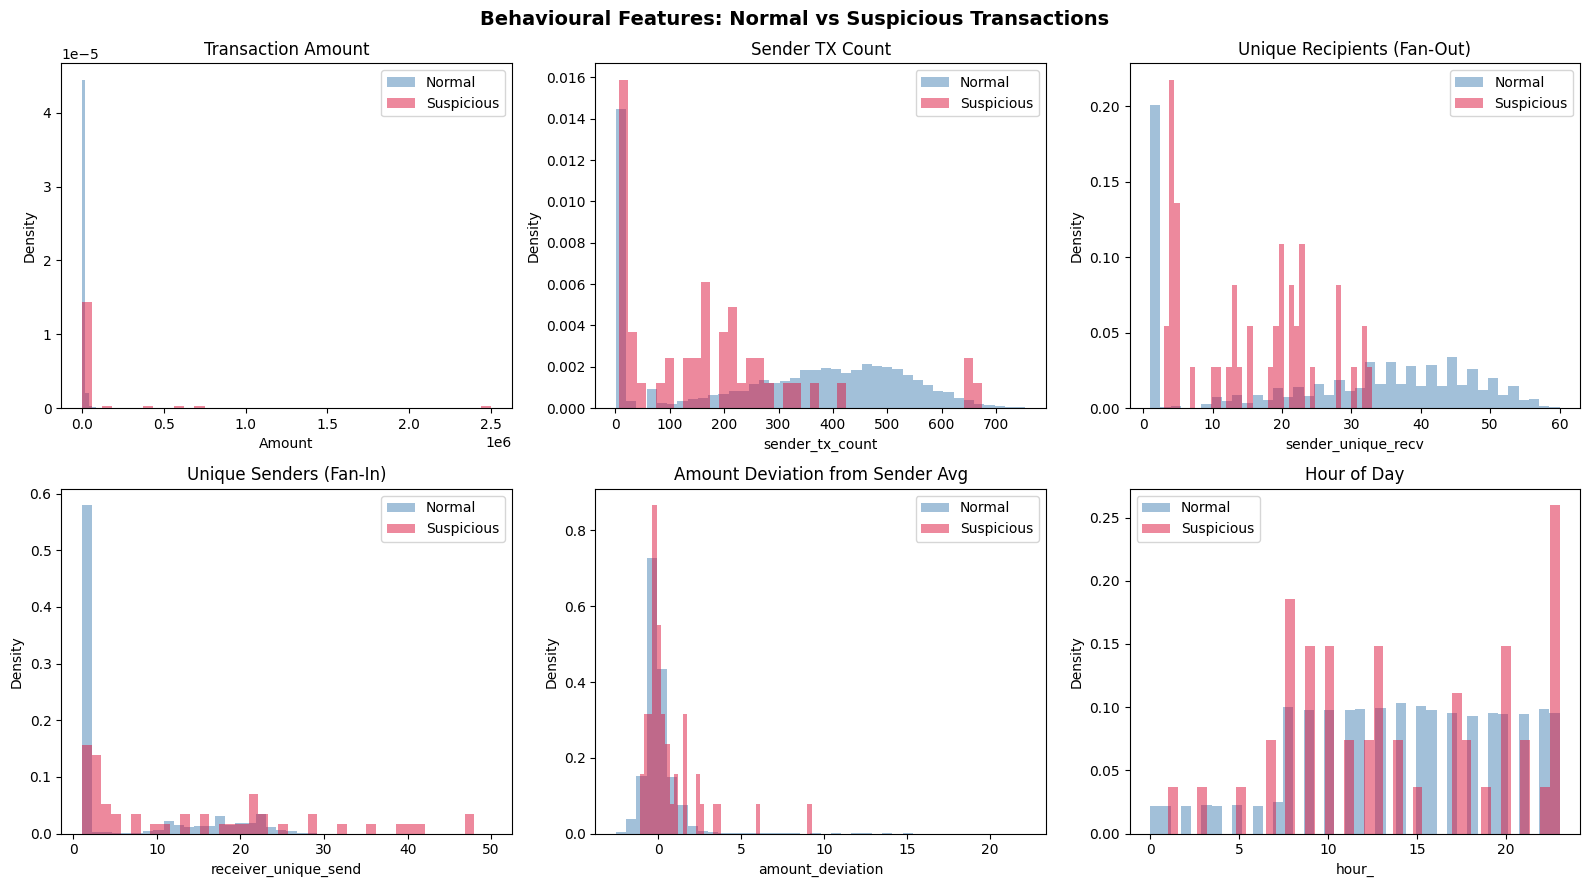

In [11]:
sample_df = df.sample(n=50000, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Behavioural Features: Normal vs Suspicious Transactions', fontsize=14, fontweight='bold')

features_to_plot = [
    ('Amount',              'Transaction Amount'),
    ('sender_tx_count',     'Sender TX Count'),
    ('sender_unique_recv',  'Unique Recipients (Fan-Out)'),
    ('receiver_unique_send','Unique Senders (Fan-In)'),
    ('amount_deviation',    'Amount Deviation from Sender Avg'),
    ('hour_',               'Hour of Day'),
]

for ax, (feat, label) in zip(axes.flatten(), features_to_plot):
    for label_val, color, name in [(0, 'steelblue', 'Normal'), (1, 'crimson', 'Suspicious')]:
        subset = sample_df[sample_df['Is_laundering'] == label_val][feat]
        ax.hist(subset, bins=40, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(label)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

In [12]:
# Cross-border and currency mismatch rates by label
print("Cross-border rate:")
print(df.groupby('Is_laundering')['cross_border'].mean().rename({0: 'Normal', 1: 'Suspicious'}))
print("\nCurrency mismatch rate:")
print(df.groupby('Is_laundering')['currency_mismatch'].mean().rename({0: 'Normal', 1: 'Suspicious'}))

Cross-border rate:
Is_laundering
Normal        0.098084
Suspicious    0.308417
Name: cross_border, dtype: float64

Currency mismatch rate:
Is_laundering
Normal        0.113977
Suspicious    0.370404
Name: currency_mismatch, dtype: float64


---
## 6. Anomaly Detection — Isolation Forest

Isolation Forest is used here as an **unsupervised pre-scoring layer**. Unlike the original version (which only used raw numeric columns), we now run it on **behavioural features** — where anomalies actually carry meaningful signal.

The resulting `anomaly_score` is used as an additional input feature for supervised models, not as a standalone classifier.

In [13]:
# Behavioural columns for Isolation Forest
iso_features = [
    'Amount', 'hour_', 'day_', 'month_',
    'sender_tx_count', 'sender_avg_amount', 'sender_std_amount',
    'sender_unique_recv', 'sender_total_amount',
    'receiver_tx_count', 'receiver_unique_send',
    'amount_deviation', 'currency_mismatch', 'cross_border',
    'is_weekend', 'is_night'
]

iso_df = df[iso_features].fillna(0)

iso_forest = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
iso_forest.fit(iso_df)
df['anomaly_score'] = iso_forest.decision_function(iso_df)

print("Anomaly score distribution:")
print(df['anomaly_score'].describe())
print(f"\nAvg anomaly score — Normal:     {df[df['Is_laundering']==0]['anomaly_score'].mean():.4f}")
print(f"Avg anomaly score — Suspicious: {df[df['Is_laundering']==1]['anomaly_score'].mean():.4f}")

Anomaly score distribution:
count    9.504852e+06
mean     1.210974e-01
std      5.035103e-02
min     -1.355118e-01
25%      9.010287e-02
50%      1.294316e-01
75%      1.595911e-01
max      2.132775e-01
Name: anomaly_score, dtype: float64

Avg anomaly score — Normal:     0.1212
Avg anomaly score — Suspicious: 0.0560


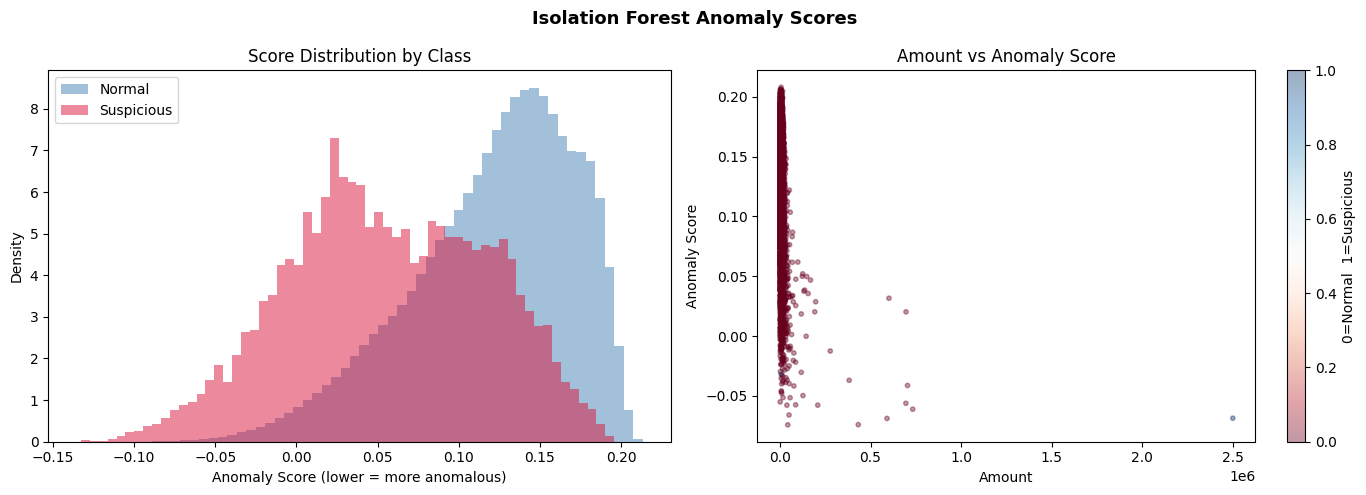

In [14]:
# Visualise anomaly score distribution by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Isolation Forest Anomaly Scores', fontsize=13, fontweight='bold')

# Histogram
for label_val, color, name in [(0, 'steelblue', 'Normal'), (1, 'crimson', 'Suspicious')]:
    axes[0].hist(df[df['Is_laundering']==label_val]['anomaly_score'],
                 bins=60, alpha=0.5, color=color, label=name, density=True)
axes[0].set_title('Score Distribution by Class')
axes[0].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Scatterplot: Amount vs anomaly score
scatter_df = df.sample(n=5000, random_state=42)
sc = axes[1].scatter(
    scatter_df['Amount'],
    scatter_df['anomaly_score'],
    c=scatter_df['Is_laundering'],
    cmap='RdBu', alpha=0.4, s=10
)
axes[1].set_title('Amount vs Anomaly Score')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Anomaly Score')
plt.colorbar(sc, ax=axes[1], label='0=Normal  1=Suspicious')

plt.tight_layout()
plt.show()

---
## 7. Correlation Analysis

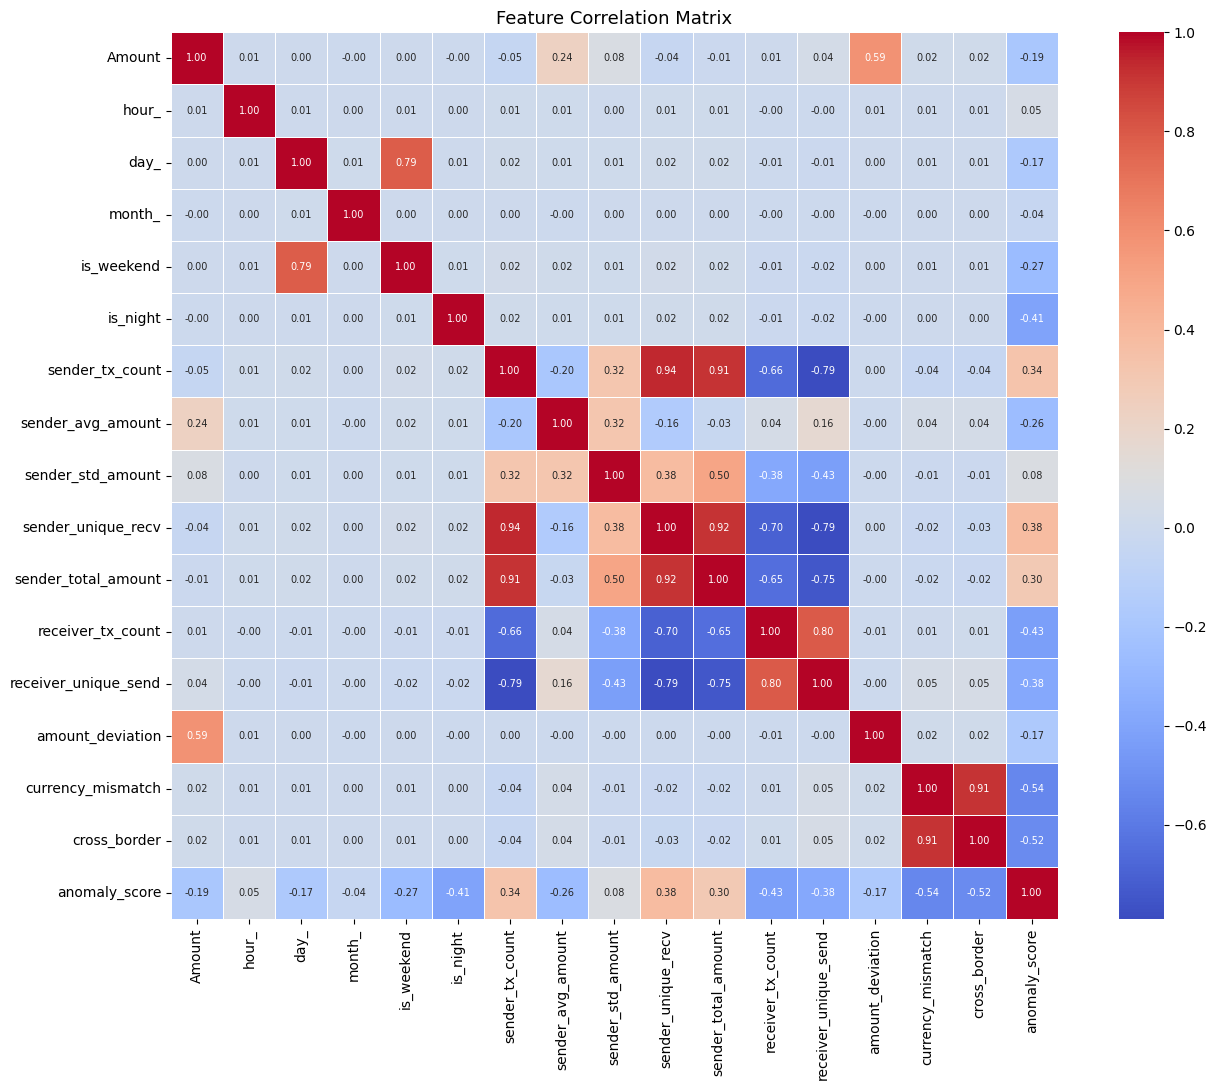

In [15]:
numeric_cols = df.select_dtypes(include='number').drop(
    columns=['Sender_account', 'Receiver_account', 'Is_laundering'], errors='ignore'
).columns

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Data Partitioning

Train/test split is performed **before** preprocessing to prevent data leakage.

In [16]:
# Drop columns not used as model features
# Sender/Receiver account IDs are dropped — behavioural aggregates computed from them are kept
drop_cols = [
    'Time', 'Date', 'timestamp', 'Laundering_type',
    'Sender_account', 'Receiver_account'
]
df_model = df.drop(columns=drop_cols, errors='ignore')

X = df_model.drop(columns=['Is_laundering'])
y = df_model['Is_laundering']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Testing set:  {X_test.shape[0]:,} rows")
print(f"\nFeatures used ({X.shape[1]}):")
for col in X.columns:
    print(f"  - {col}")

Training set: 7,603,881 rows
Testing set:  1,900,971 rows

Features used (22):
  - Amount
  - Payment_currency
  - Received_currency
  - Sender_bank_location
  - Receiver_bank_location
  - Payment_type
  - hour_
  - day_
  - month_
  - is_weekend
  - is_night
  - sender_tx_count
  - sender_avg_amount
  - sender_std_amount
  - sender_unique_recv
  - sender_total_amount
  - receiver_tx_count
  - receiver_unique_send
  - amount_deviation
  - currency_mismatch
  - cross_border
  - anomaly_score


---
## 9. Preprocessing

In [17]:
num_columns = X.select_dtypes(include=[np.number]).columns.tolist()
cat_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical features ({len(num_columns)}): {num_columns}")
print(f"Categorical features ({len(cat_columns)}): {cat_columns}")

Numerical features (17): ['Amount', 'hour_', 'day_', 'month_', 'is_weekend', 'is_night', 'sender_tx_count', 'sender_avg_amount', 'sender_std_amount', 'sender_unique_recv', 'sender_total_amount', 'receiver_tx_count', 'receiver_unique_send', 'amount_deviation', 'currency_mismatch', 'cross_border', 'anomaly_score']
Categorical features (5): ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']


In [18]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_columns),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=True), cat_columns)
])

X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)

print(f"Preprocessed training shape: {X_train_pp.shape}")
print(f"Preprocessed testing shape:  {X_test_pp.shape}")

Preprocessed training shape: (7603881, 81)
Preprocessed testing shape:  (1900971, 81)


---
## 10. Low-Variance Feature Removal

In [19]:
all_feature_names = preprocessor.get_feature_names_out()

selector = VarianceThreshold(0.01)
X_train_final = selector.fit_transform(X_train_pp)
X_test_final  = selector.transform(X_test_pp)

selected_features = np.array(all_feature_names)[selector.get_support()]
removed_count = len(all_feature_names) - len(selected_features)

print(f"Features before: {len(all_feature_names)}")
print(f"Features after:  {len(selected_features)}  ({removed_count} removed as low-variance)")
print("\nKept features:")
for f in selected_features:
    print(f"  {f}")

Features before: 81
Features after:  29  (52 removed as low-variance)

Kept features:
  num__Amount
  num__hour_
  num__day_
  num__month_
  num__is_weekend
  num__is_night
  num__sender_tx_count
  num__sender_avg_amount
  num__sender_std_amount
  num__sender_unique_recv
  num__sender_total_amount
  num__receiver_tx_count
  num__receiver_unique_send
  num__amount_deviation
  num__currency_mismatch
  num__cross_border
  num__anomaly_score
  cat__Payment_currency_Euro
  cat__Payment_currency_UK pounds
  cat__Received_currency_Euro
  cat__Received_currency_UK pounds
  cat__Sender_bank_location_UK
  cat__Receiver_bank_location_UK
  cat__Payment_type_Cash Deposit
  cat__Payment_type_Cash Withdrawal
  cat__Payment_type_Cheque
  cat__Payment_type_Credit card
  cat__Payment_type_Cross-border
  cat__Payment_type_Debit card


---
## 11. Class Imbalance — SMOTE

The dataset is heavily imbalanced. SMOTE synthetically generates minority-class samples **in the training set only**, after the train/test split. This prevents leakage and gives classifiers a balanced training signal.

In [20]:
print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_final, y_train)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

Class distribution before SMOTE:
Is_laundering
0    7595983
1       7898
Name: count, dtype: int64

Class distribution after SMOTE:
Is_laundering
0    7595983
1    7595983
Name: count, dtype: int64


---
## 12. Model Selection & Training

We train four classifiers suited to large, imbalanced tabular datasets.

**Key improvement from original:** `class_weight='balanced'` is set on applicable models. This means models are penalised more for missing a suspicious transaction than for a false alarm — critical for fraud detection where missing a true positive is costly.

**Evaluation metric:** Precision-Recall AUC (`average_precision`) is used alongside F1. On heavily imbalanced data, ROC AUC can be misleadingly optimistic. PR-AUC is a stricter measure of how well the model identifies the rare positive class.

In [21]:
lr_model = LogisticRegression(
    solver='saga', random_state=42, max_iter=5000,
    class_weight='balanced'   # penalise misclassifying suspicious transactions more heavily
)

rf_model = RandomForestClassifier(
    random_state=42, n_jobs=-1,
    class_weight='balanced'
)

ad_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    random_state=42
)

nb_model = GaussianNB()

models = {
    'LogisticRegression':    lr_model,
    'RandomForestClassifier': rf_model,
    'AdaBoostClassifier':    ad_model,
    'GaussianNB':            nb_model
}
print("Models defined.")

Models defined.


---
## 13. Hyperparameter Tuning

Tuning is performed on a **stratified 2% subset** of the resampled training data for computational efficiency.  
Primary scoring metric: `f1` — balances precision and recall for the positive (suspicious) class.

In [22]:
# Draw a stratified 2% tuning subset
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.98, random_state=42)
for train_idx, _ in sss.split(X_train_res, y_train_res):
    X_tune = X_train_res[train_idx]
    y_tune = y_train_res[train_idx]

print(f"Tuning subset size: {X_tune.shape[0]:,} rows")

Tuning subset size: 303,839 rows


In [23]:
# Logistic Regression — GridSearchCV
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'max_iter': [2000, 5000]
}
lr_search = GridSearchCV(lr_model, lr_params, scoring='f1', cv=5, n_jobs=-1)
lr_search.fit(X_tune, y_tune)
best_lr = lr_search.best_estimator_
print("Best LR params:", lr_search.best_params_)

Best LR params: {'C': 10, 'max_iter': 2000, 'solver': 'liblinear'}


In [24]:
# Random Forest — RandomizedSearchCV
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', 'balanced_subsample']
}
rf_search = RandomizedSearchCV(rf_model, rf_params, n_iter=20, scoring='f1', cv=5, random_state=42, n_jobs=-1)
rf_search.fit(X_tune, y_tune)
best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced'}


In [25]:
# AdaBoost — GridSearchCV
ad_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.5, 1.0],
    'estimator__max_depth': [2, 3, 4]
}
ad_search = GridSearchCV(ad_model, ad_params, scoring='f1', cv=5, n_jobs=-1)
ad_search.fit(X_tune, y_tune)
best_ad = ad_search.best_estimator_
print("Best AdaBoost params:", ad_search.best_params_)

Best AdaBoost params: {'estimator__max_depth': 4, 'learning_rate': 1.0, 'n_estimators': 200}


In [26]:
# GaussianNB — no hyperparameter tuning (no meaningful parameters)
X_tune_dense = X_tune.toarray() if issparse(X_tune) else X_tune
nb_model.fit(X_tune_dense, y_tune)
print("GaussianNB fitted.")

GaussianNB fitted.


---
## 14. Model Evaluation

Models are evaluated on the held-out 20% test set.  
We report: Precision, Recall, F1, ROC AUC, PR AUC, and Confusion Matrices.

**Metrics explained in fraud detection context:**
- **Precision** — of transactions flagged as suspicious, what fraction actually are? Low precision → many false alarms → analyst fatigue.
- **Recall** — of all actual suspicious transactions, what fraction did we catch? Low recall → criminals slipping through.
- **F1** — harmonic mean of precision and recall. The main selection criterion.
- **PR AUC** — area under the precision-recall curve. More meaningful than ROC AUC on heavily imbalanced data.

In [27]:
def evaluate_model(name, model, X_test, y_test, dense=False):
    Xd = X_test.toarray() if (dense and issparse(X_test)) else X_test
    y_pred  = model.predict(Xd)
    y_proba = model.predict_proba(Xd)[:, 1] if hasattr(model, 'predict_proba') else None

    prec   = precision_score(y_test, y_pred, zero_division=0)
    rec    = recall_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    roc    = roc_auc_score(y_test, y_proba if y_proba is not None else y_pred)
    pr_auc = average_precision_score(y_test, y_proba if y_proba is not None else y_pred)

    print(f"\n{'='*50}")
    print(f" Model: {name}")
    print(f"{'='*50}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC AUC   : {roc:.4f}")
    print(f"  PR AUC    : {pr_auc:.4f}")
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Suspicious']))

    return {
        'name': name, 'precision': prec, 'recall': rec,
        'f1': f1, 'roc_auc': roc, 'pr_auc': pr_auc,
        'y_pred': y_pred, 'y_proba': y_proba, 'cm': cm
    }

results = {}
results['LR']  = evaluate_model('Logistic Regression',   best_lr, X_test_final, y_test)
results['RF']  = evaluate_model('Random Forest',         best_rf, X_test_final, y_test)
results['AD']  = evaluate_model('AdaBoost',              best_ad, X_test_final, y_test)
results['NB']  = evaluate_model('GaussianNB',            nb_model, X_test_final, y_test, dense=True)


 Model: Logistic Regression
  Precision : 0.0111
  Recall    : 0.8785
  F1 Score  : 0.0218
  ROC AUC   : 0.9671
  PR AUC    : 0.1748

Confusion Matrix:
[[1743783  155213]
 [    240    1735]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96   1898996
  Suspicious       0.01      0.88      0.02      1975

    accuracy                           0.92   1900971
   macro avg       0.51      0.90      0.49   1900971
weighted avg       1.00      0.92      0.96   1900971


 Model: Random Forest
  Precision : 0.9899
  Recall    : 0.9914
  F1 Score  : 0.9906
  ROC AUC   : 0.9999
  PR AUC    : 0.9955

Confusion Matrix:
[[1898976      20]
 [     17    1958]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1898996
  Suspicious       0.99      0.99      0.99      1975

    accuracy                           1.00   1900971
   macro avg       0.99      

In [28]:
# Summary comparison table
summary = pd.DataFrame([
    {
        'Model': r['name'],
        'Precision': round(r['precision'], 4),
        'Recall':    round(r['recall'],    4),
        'F1':        round(r['f1'],        4),
        'ROC AUC':   round(r['roc_auc'],   4),
        'PR AUC':    round(r['pr_auc'],    4),
    }
    for r in results.values()
])
summary = summary.sort_values('F1', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

              Model  Precision  Recall     F1  ROC AUC  PR AUC
      Random Forest     0.9899  0.9914 0.9906   0.9999  0.9955
           AdaBoost     0.9899  0.9914 0.9906   0.9998  0.9938
Logistic Regression     0.0111  0.8785 0.0218   0.9671  0.1748
         GaussianNB     0.0050  0.6709 0.0098   0.8592  0.0069


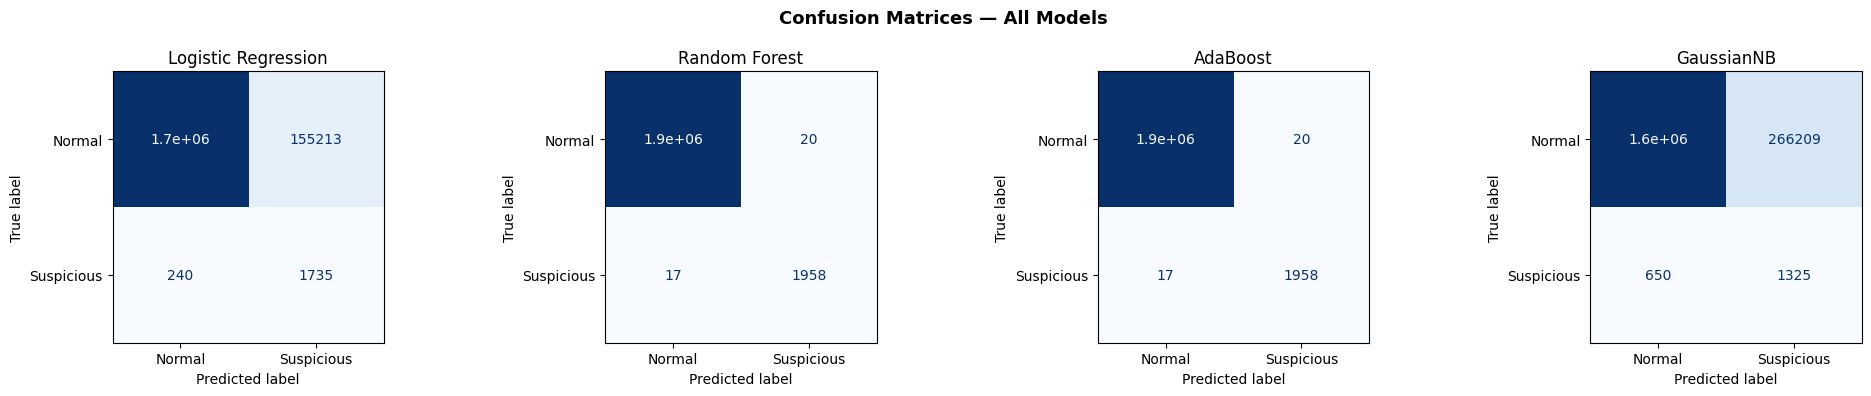

In [29]:
# Confusion matrix grid
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')

for ax, (key, r) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=['Normal', 'Suspicious'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(r['name'])

plt.tight_layout()
plt.show()

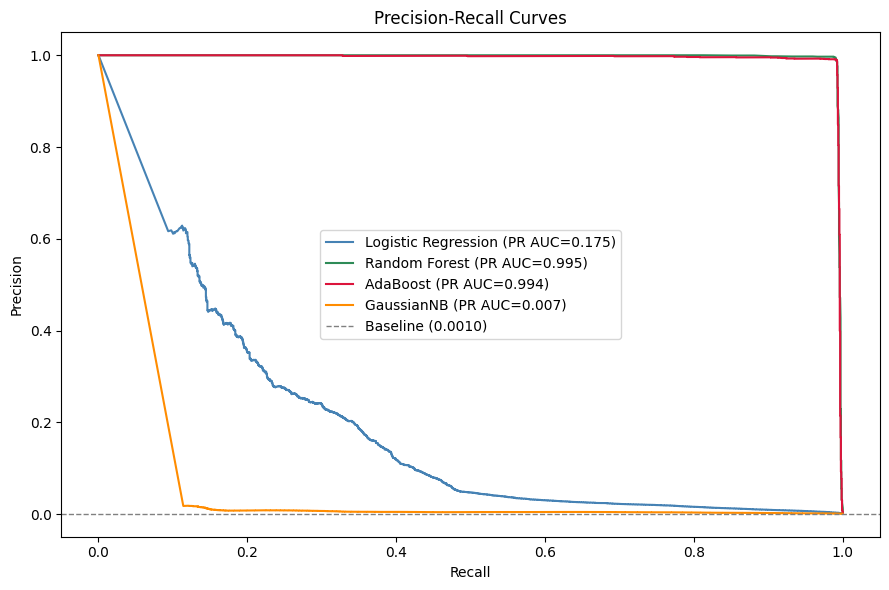

In [30]:
# Precision-Recall curves for all models (more informative than ROC on imbalanced data)
plt.figure(figsize=(9, 6))
colours = ['steelblue', 'seagreen', 'crimson', 'darkorange']

for (key, r), colour in zip(results.items(), colours):
    if r['y_proba'] is not None:
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, r['y_proba'])
        plt.plot(recall_vals, precision_vals, lw=1.5, color=colour,
                 label=f"{r['name']} (PR AUC={r['pr_auc']:.3f})")

baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, color='grey', linestyle='--', lw=1, label=f'Baseline ({baseline:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.tight_layout()
plt.show()

---
## 15. Feature Importance — Best Model

Understanding which features drive predictions is important for both model trust and regulatory explainability.

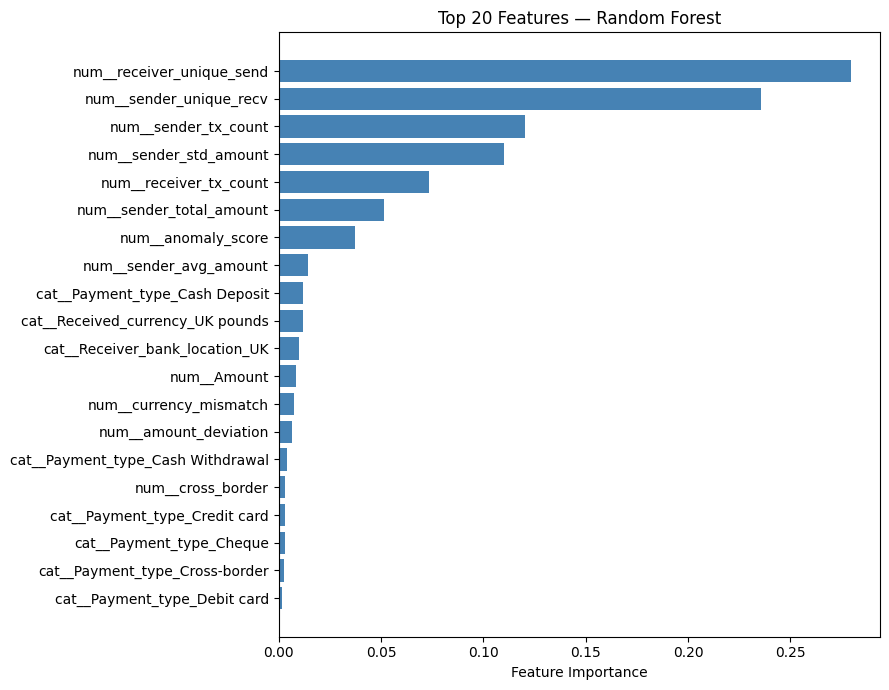

In [31]:
# Use Random Forest for feature importance (most interpretable for this)
importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature': selected_features,
    'importance': importances
}).sort_values('importance', ascending=True).tail(20)

plt.figure(figsize=(9, 7))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 20 Features — Random Forest')
plt.tight_layout()
plt.show()

---
## 16. Save Best Model

In [32]:
# Select best model by F1
best_key = max(results, key=lambda k: results[k]['f1'])
best_result = results[best_key]
best_model_obj = {'LR': best_lr, 'RF': best_rf, 'AD': best_ad, 'NB': nb_model}[best_key]

print(f"Best model: {best_result['name']} (F1={best_result['f1']:.4f})")

joblib.dump(best_model_obj, 'safeflow_best_model.joblib')
joblib.dump(preprocessor,   'safeflow_preprocessor.joblib')
joblib.dump(selector,       'safeflow_selector.joblib')

print("Model, preprocessor, and selector saved.")

Best model: Random Forest (F1=0.9906)
Model, preprocessor, and selector saved.


---
## 17. Flagging & Alert Demo

This section simulates what a real-time alert system would produce. For each suspicious transaction detected, we output a structured alert with transaction details and risk signals.

In [33]:
loaded_model = joblib.load('safeflow_best_model.joblib')

# Sample from true positives in the test set
pos_indices = np.where(y_test.values == 1)[0]
sample_idx  = random.choice(pos_indices)

sample_features = X_test_final[sample_idx]
if issparse(sample_features):
    sample_features = sample_features.toarray()
sample_features = sample_features.reshape(1, -1)

pred  = loaded_model.predict(sample_features)[0]
proba = loaded_model.predict_proba(sample_features)[0][1] if hasattr(loaded_model, 'predict_proba') else None
actual = y_test.iloc[sample_idx]

# Retrieve original row from df using test-set index
orig_idx = y_test.index[sample_idx]
row = df.loc[orig_idx]

print("=" * 55)
print("         SAFEFLOW AI — TRANSACTION ALERT")
print("=" * 55)
print(f"  Actual Label    : {'⚠️  SUSPICIOUS' if actual == 1 else '✅ Normal'}")
print(f"  Predicted Label : {'⚠️  SUSPICIOUS' if pred == 1 else '✅ Normal'}")
if proba is not None:
    print(f"  Risk Score      : {proba:.4f}")
print("-" * 55)
print("  TRANSACTION DETAILS")
print(f"  Date            : {row['Date']}")
print(f"  Time            : {row['Time']}")
print(f"  Amount          : {row['Payment_currency']} {row['Amount']:,.2f}")
print(f"  Payment Type    : {row['Payment_type']}")
print(f"  Sender Bank     : {row['Sender_bank_location']}")
print(f"  Receiver Bank   : {row['Receiver_bank_location']}")
print(f"  Currency Change : {'Yes ⚠️' if row['currency_mismatch'] == 1 else 'No'}")
print(f"  Cross-border    : {'Yes ⚠️' if row['cross_border'] == 1 else 'No'}")
print(f"  Time of Day     : {'Night ⚠️' if row['is_night'] == 1 else 'Day'}")
print(f"  Weekend         : {'Yes ⚠️' if row['is_weekend'] == 1 else 'No'}")
print("-" * 55)
print("  BEHAVIOURAL CONTEXT")
print(f"  Sender TX Count : {int(row['sender_tx_count'])}")
print(f"  Sender Avg Amt  : {row['sender_avg_amount']:,.2f}")
print(f"  Amount Deviation: {row['amount_deviation']:+.2f}x avg")
print(f"  Unique Recipients: {int(row['sender_unique_recv'])} (fan-out)")
print(f"  Unique Senders  : {int(row['receiver_unique_send'])} (fan-in)")
print("=" * 55)

         SAFEFLOW AI — TRANSACTION ALERT
  Actual Label    : ⚠️  SUSPICIOUS
  Predicted Label : ⚠️  SUSPICIOUS
  Risk Score      : 1.0000
-------------------------------------------------------
  TRANSACTION DETAILS
  Date            : 2023-02-09
  Time            : 15:35:42
  Amount          : UK pounds 11,112.95
  Payment Type    : ACH
  Sender Bank     : UK
  Receiver Bank   : UK
  Currency Change : No
  Cross-border    : No
  Time of Day     : Day
  Weekend         : No
-------------------------------------------------------
  BEHAVIOURAL CONTEXT
  Sender TX Count : 179
  Sender Avg Amt  : 9,498.16
  Amount Deviation: +0.11x avg
  Unique Recipients: 21 (fan-out)
  Unique Senders  : 14 (fan-in)
